# DeepPod: CNN-based fruit (silique) number quantification in *Arabidopsis* — minimal reproduction

**Paper**: M. Ghahremani et al., "DeepPod: a convolutional neural network based quantification of fruit number in *Arabidopsis*",
*GigaScience* 9(3):giaa012, 2020. DOI: [10.1093/gigascience/giaa012](https://doi.org/10.1093/gigascience/giaa012) (PMC7055469).

**Author code**: https://github.com/AzmHmd/DeepPod — pinned commit `d7cff986c9a64766ca5351d1cce7e04ca493944d` (MIT license).

**What this notebook does (executed scope)**:
1. Loads the authors' pretrained **DenseNet** patch classifier (Caffe `snapshot_iter_157380.caffemodel` + `deploy.prototxt`) and converts the weights **layer-by-layer** to PyTorch *inside this notebook*.
2. Verifies the converted classifier on the authors' own validation LMDB (`val_db`) against the paper-reported validation accuracy (DenseNet 86.80%).
3. Downloads **one** scanned inflorescence image with its manual point annotations from the paper-linked GigaDB record 100704 (three Set-1 samples are published individually; the full Set_1/Set_2 archives on the Aberystwyth portal are currently unreachable from datacenter clients).
4. Reproduces the paper's counting pipeline on that single image: patching (authors' `Demo_Patching` logic), patch classification, sub-patch voting reconstruction, and silique counting (authors' `funcTiling` / `funcSiliqdef` / `funcSiliqCounting`).
5. Compares the automated count with the annotation-derived reference fruit count (number of manually annotated tips/bases).

> **⚠️ AI-assisted conversion notice / AI支援による変換に関する注意**
> **EN:** The authors released this method for MATLAB 9.3 + Caffe 1.0-rc3 (CUDA 8.0/CuDNN 5.1/DIGITS 5.1). That legacy stack is not provisionable in current Colab, so this notebook is an **AI-assisted port**: the authors' MATLAB counting functions are run **verbatim** in GNU Octave, and the Caffe weights are converted to PyTorch at runtime using the authors' own `deploy.prototxt` and `caffe.proto`. The executed example and listed checks were validated, but untested behavior is not guaranteed. This is a faithful single-example demonstration, **not** verification of the paper's dataset-level results (Set-2 R²=0.90).
> **JA:** 著者は MATLAB 9.3 + Caffe 1.0-rc3 用に本手法を公開していますが、現行 Colab では実行できないため、本ノートブックは AI による移植版です。著者の MATLAB カウント関数は GNU Octave で**原文のまま**実行し、Caffe 重みは著者の `deploy.prototxt` と `caffe.proto` を用いて実行時に PyTorch へ変換します。検証済みの例示はされていますが、未検証の挙動は保証されません。単一サンプルの再現であり、論文のデータセット全体の結果の検証ではありません。


## Runtime selection / ランタイム選択

**EN:** `Runtime → Change runtime type`: **T4 GPU is recommended** (patch classification of ~20–70k patches is much faster); the notebook also runs end-to-end on **CPU** (adds roughly 5–15 min). Everything else (Octave image processing) is CPU-bound either way. Expected wall time: ~10 min setup+data, classification ≈1 min (T4) / ≈5–15 min (CPU), counting ~1–3 min.
**JA:** `ランタイム → ランタイムのタイプを変更` で **T4 GPU を推奨**（パッチ分類が高速化）。**CPU でも全体が完走します**（+5〜15 分程度）。その他の画像処理（Octave）はどちらも CPU です。

**Downloads in this notebook**: authors' code + model artifacts from GitHub (~7 MB), one image + annotations from Aberystwyth (~10 MB). No training is performed.


### 1. Environment setup / 環境セットアップ

**EN:** We install GNU Octave with its image package (to run the authors' MATLAB functions unchanged) plus two small Python packages: `lmdb` (read the authors' validation database) and `grpcio-tools` (compile `caffe.proto` to parse the Caffe model). PyTorch, NumPy, SciPy, Pillow and matplotlib are preinstalled on Colab.
**JA:** 著者の MATLAB 関数をそのまま実行するため GNU Octave（image パッケージ付き）を、検証 DB 読み取り用 `lmdb`、Caffe モデル解析用 `grpcio-tools` をインストールします。PyTorch 等は Colab にプリインストール済みです。


In [ ]:
import subprocess, sys, time

t_setup = time.time()
def sh(cmd, capture=False):
    print("+", " ".join(cmd))
    if capture:
        r = subprocess.run(cmd, capture_output=True, text=True)
        if r.stdout: print(r.stdout[-4000:])
        if r.returncode != 0:
            print(r.stderr[-4000:])
            raise RuntimeError(f"command failed ({r.returncode}): {' '.join(cmd)}")
        return r
    r = subprocess.run(cmd)
    if r.returncode != 0:
        raise RuntimeError(f"command failed ({r.returncode}): {' '.join(cmd)}")
    return r

for pkg in ["lmdb", "grpcio-tools"]:
    sh([sys.executable, "-m", "pip", "install", "-q", pkg])
sh(["apt-get", "-qq", "update"])
r = subprocess.run(["apt-get", "install", "-y", "-qq", "octave", "octave-image"])
if r.returncode != 0:
    raise RuntimeError("apt-get install octave octave-image failed; see output above")
sh(["octave", "--eval", "disp(['Octave ' version]); pkg load image; disp('image package OK')"], capture=True)
print(f"setup finished in {time.time()-t_setup:.0f} s")


+ /usr/bin/python3 -m pip install -q lmdb


+ /usr/bin/python3 -m pip install -q grpcio-tools


+ apt-get -qq update


+ octave --eval disp(['Octave ' version]); pkg load image; disp('image package OK')
Octave 8.4.0
image package OK

setup finished in 63 s


### 2. Fetch the authors' pinned code and model artifacts / 著者コードとモデルの取得

**EN:** Everything is fetched from the pinned DeepPod commit `d7cff986` and verified against the GitHub **git blob SHA-1** recorded from the repository tree, so any altered/mismatched byte fails loudly. The `.caffemodel`, LMDB and mean file are **weights/data and are downloaded here on the Colab VM only**.
**JA:** すべて pinned コミット `d7cff986` から取得し、リポジトリ木から記録した git blob SHA-1 で検証します（不一致ならエラー）。`.caffemodel`・LMDB・mean ファイルは重み/データとして **Colab VM 上でのみ**ダウンロードします。


In [ ]:
import hashlib, pathlib, urllib.parse
import requests

COMMIT = "d7cff986c9a64766ca5351d1cce7e04ca493944d"
RAW_BASE = f"https://raw.githubusercontent.com/AzmHmd/DeepPod/{COMMIT}"
# path in repo -> git blob SHA-1 (from the GitHub tree of the pinned commit)
FILES = {
    "LICENSE.txt": "84a7ecff03844a351f846a18d6657b5e647510cf",
    "silique counting/Partitioning.m": "57bd8d3a5342fe3787ab34329957a444f467cb26",
    "silique counting/PatchCentralization.m": "c382cdfdf3c00ba29c948464cf2cab2d3bafe932",
    "silique counting/PatchCoordination.m": "4d9aa28aacc271901c48cfb5ba90069fcc1f0f57",
    "silique counting/Tiling.m": "5b3bf12974af7cf1a6d9ee0ab0f1b134a1b272ce",
    "silique counting/TilingOverlapped.m": "3245e288dc520b280d78db7e608c1b019a9f2346",
    "silique counting/Labeling_n.m": "a1e8ff2ad98a52c148d967e69bf92696c13e3837",
    "silique counting/funcReadData.m": "5f292dfdf403fe501901374f4ce978808bfddf6c",
    "silique counting/funcSiliqdef.m": "40a5f909b826c97eb946c01b10094cccb2f0b3b9",
    "silique counting/funcSiliqCounting.m": "fe5d49ec810bcc9cc83ccb1190d6bb82c76941f9",
    "silique counting/funcTiling.m": "72c06ae62ac253d0031bd00c63d0ba97254413c7",
    "silique counting/Demo_Patching.m": "f2966920512733fc309f4f57ddc15968ddb665fa",
    "silique counting/Demo_counter.m": "dea54b491f8c90c674d286edb272c4e3c308a266",
    "trained models/densenet/deploy.prototxt": "08953a5ba43f4e9b45314c91ef293a69330d9d51",
    "trained models/densenet/snapshot_iter_157380.caffemodel": "cf6445a5db0fbcd175b9529f8407853513f145f2",
    "trained models/training and validation sets/labels.txt": "32720328372c4cbe4d8d2febd715a3aa97b467d6",
    "trained models/training and validation sets/mean.binaryproto": "350311b3b55dde0ca73f02c01961d89a2f6286e8",
    "trained models/training and validation sets/val.txt": "d4ed8f81d6722c1dc4b8d0b61c51b5050b222225",
    "trained models/training and validation sets/val_db/data.mdb": "891963fb0418e698fae74e0d8defbb49562ec39d",
    "trained models/training and validation sets/val_db/lock.mdb": "db9b63a5a38ea03aa4b5ce884d0d2e57ee8b3f42",
}

HEADERS = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) Colab-notebook/1.0 (research reproduction)"}

def fetch(url):
    last = None
    for attempt in range(3):
        try:
            r = requests.get(url, timeout=120, headers=HEADERS)
            r.raise_for_status()
            return r.content
        except Exception as e:
            last = e
            print(f"retry {attempt+1} for {url}: {e}")
    raise RuntimeError(f"download failed: {url} ({last})")

def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

DEEPPOD = pathlib.Path("/content/deeppod")
for path, sha in FILES.items():
    data = fetch(f"{RAW_BASE}/{urllib.parse.quote(path)}")
    got = blob_sha1(data)
    assert got == sha, f"git blob SHA mismatch for {path}: got {got}, expected {sha}"
    dest = DEEPPOD / path
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(data)
    print(f"{len(data):>9} B  OK  {path}")
print()
print(DEEPPOD.joinpath("LICENSE.txt").read_text()[:180])


     1073 B  OK  LICENSE.txt


     2575 B  OK  silique counting/Partitioning.m


     3244 B  OK  silique counting/PatchCentralization.m
      569 B  OK  silique counting/PatchCoordination.m


     4849 B  OK  silique counting/Tiling.m
     2737 B  OK  silique counting/TilingOverlapped.m


      235 B  OK  silique counting/Labeling_n.m


...

    43952 B  OK  trained models/densenet/deploy.prototxt


  4169106 B  OK  trained models/densenet/snapshot_iter_157380.caffemodel
       19 B  OK  trained models/training and validation sets/labels.txt


    12299 B  OK  trained models/training and validation sets/mean.binaryproto


    17643 B  OK  trained models/training and validation sets/val.txt


   520192 B  OK  trained models/training and validation sets/val_db/data.mdb
     8192 B  OK  trained models/training and validation sets/val_db/lock.mdb

MIT License

Copyright (c) 2019 Azam Hamidinekoo

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (


### 3. Convert the Caffe DenseNet to PyTorch at runtime / Caffe DenseNet の PyTorch 変換

**EN:** The architecture is **not** hardcoded from memory: the pinned `deploy.prototxt` is parsed and a layer-by-layer forward graph (Convolution / BatchNorm+Scale / ReLU / Dropout / Concat / AvgPooling / InnerProduct / Softmax) is built from it. The weights come from `snapshot_iter_157380.caffemodel`, parsed with the Caffe project's own `caffe.proto` (pinned to BVLC/caffe `9b89154`). Caffe `BatchNorm` stores (mean, variance, moving-average-factor), so we renormalize by the factor and use Caffe's default epsilon 1e-5.
**JA:** ネットワーク構造は記憶ではなく pinned な `deploy.prototxt` を解釈して構築します。重みは `caffe.proto`（BVLC/caffe をピン留め）で `caffemodel` をパースして層ごとに写します。Caffe の BatchNorm は (平均, 分散, 移動平均係数) を持つため、係数で正規化し ε=1e-5 を用います。


In [ ]:
import pathlib, re, sys
import numpy as np
import requests

CAFFE_PROTO_COMMIT = "9b891540183ddc834a02b2bd81b31afae71b2153"
CAFFE_PROTO_BLOB = "3dcad697f6dc6cad278c8f4e4b9dc0db47861045"
proto_dir = pathlib.Path("/content/caffe_proto")
proto_dir.mkdir(exist_ok=True)
proto_bytes = fetch(f"https://raw.githubusercontent.com/BVLC/caffe/{CAFFE_PROTO_COMMIT}/src/caffe/proto/caffe.proto")
assert blob_sha1(proto_bytes) == CAFFE_PROTO_BLOB, "caffe.proto blob SHA mismatch"
proto_text = proto_bytes.decode("utf-8")
# The DeepPod caffemodel was written by a Caffe fork whose BlobProto stores the
# packed float weights on field 12 (BVLC master leaves that field unused and
# puts weights on field 5). We add the field explicitly and verify empirically
# below (conv1 blob = 16*3*3*3 floats). Verified 2026-10-06 on the pinned file.
proto_text = proto_text.replace("package caffe;", "package deeppod_caffe;", 1)
marker = "repeated double double_diff = 9 [packed = true];"
assert marker in proto_text
proto_text = proto_text.replace(marker, marker + "\n  repeated float fork_data = 12 [packed = true];", 1)
# unique file/module name so repeated runs never collide in the descriptor pool
(proto_dir / "deeppod_caffe.proto").write_text(proto_text)

import subprocess
rc = subprocess.run([sys.executable, "-m", "grpc_tools.protoc", "-I", str(proto_dir),
                     f"--python_out={proto_dir}", str(proto_dir / "deeppod_caffe.proto")],
                    capture_output=True, text=True)
assert rc.returncode == 0, f"protoc failed: {rc.stderr[-500:]}"
sys.path.insert(0, str(proto_dir))
import deeppod_caffe_pb2 as caffe_pb2
print("deeppod_caffe_pb2 OK, BlobProto fields:", [f.name for f in caffe_pb2.BlobProto.DESCRIPTOR.fields])


deeppod_caffe_pb2 OK, BlobProto fields: ['shape', 'data', 'diff', 'double_data', 'double_diff', 'fork_data', 'num', 'channels', 'height', 'width']


**EN:** The cell below parses `deploy.prototxt` into a layer list, loads every blob of `snapshot_iter_157380.caffemodel` (including the BatchNorm moving-average factors), and defines a forward function that executes the parsed graph in PyTorch on the detected device. Layer types not needed by this model raise an explicit error.
**JA:** 次のセルで `deploy.prototxt` を層リストとして解釈し、`caffemodel` の全 blob（BatchNorm の移動平均係数を含む）を読み込み、検出デバイス上でグラフを実行する forward 関数を定義します。未対応の層型は明示的にエラーとします。


In [ ]:
import torch
import torch.nn.functional as F

deploy_text = (DEEPPOD / "trained models/densenet/deploy.prototxt").read_text()

def parse_prototxt(text):
    pos = 0
    n = len(text)
    def skip_ws():
        nonlocal pos
        while pos < n:
            c = text[pos]
            if c in " \t\r\n":
                pos += 1
            elif c == "#":
                while pos < n and text[pos] != "\n":
                    pos += 1
            else:
                return
    def value():
        nonlocal pos
        skip_ws()
        if text[pos] == '"':
            j = text.index('"', pos + 1)
            v = text[pos + 1:j]
            pos = j + 1
            return v
        m = re.match(r"[^ \t\r\n{},]+", text[pos:])
        pos += m.end()
        return m.group(0)
    def block():
        nonlocal pos
        d = {}
        while True:
            skip_ws()
            if pos >= n:
                return d
            if text[pos] == "}":
                pos += 1
                return d
            m = re.match(r"[A-Za-z_][A-Za-z0-9_]*", text[pos:])
            key = m.group(0)
            pos += m.end()
            skip_ws()
            if pos < n and text[pos] == "{":
                pos += 1
                d.setdefault(key, []).append(block())
            else:
                if pos < n and text[pos] == ":":
                    pos += 1
                d.setdefault(key, []).append(value())
    return block()

net_def = parse_prototxt(deploy_text)
layers = net_def["layer"]
print("layers parsed:", len(layers))
print("input:", net_def.get("input_shape", net_def.get("input_dim")))

# Build executable graph: keep only layer types used by this deploy file.
TYPES = {L["type"][0] for L in layers}
print("layer types:", sorted(TYPES))

W = {}
CAFFE_BN_EPS = 1e-5
def blob_src(b):
    # the authors' Caffe fork stores blob payloads on field 12 (fork_data)
    return b.data if len(b.data) else b.fork_data

net = caffe_pb2.NetParameter()
net.ParseFromString((DEEPPOD / "trained models/densenet/snapshot_iter_157380.caffemodel").read_bytes())
shape_of = {}
def blob_arr(layer, i):
    blob = layer.blobs[i]
    if blob.shape.dim:
        shape = list(blob.shape.dim)
    else:
        shape = [blob.num, blob.channels, blob.height, blob.width]
    src = blob.data if len(blob.data) else blob.fork_data
    assert len(src) > 0, f"no weight bytes for {layer.name} blob {i}"
    arr = np.asarray(src, dtype=np.float32).reshape(shape)
    shape_of[(layer.name, i)] = shape
    return arr

for layer in net.layer:
    if not layer.blobs:
        continue
    if layer.type == "Convolution":
        W[layer.name + ".w"] = torch.from_numpy(blob_arr(layer, 0))
        if layer.convolution_param.bias_term and len(layer.blobs) > 1:
            W[layer.name + ".b"] = torch.from_numpy(blob_arr(layer, 1).flatten())
    elif layer.type == "InnerProduct":
        arr = blob_arr(layer, 0)
        n_out = layer.inner_product_param.num_output
        if arr.ndim == 1 and arr.size % n_out == 0:
            arr = arr.reshape(n_out, arr.size // n_out)  # fork stores IP weights flat
        W[layer.name + ".w"] = torch.from_numpy(arr)
        if layer.inner_product_param.bias_term and len(layer.blobs) > 1:
            W[layer.name + ".b"] = torch.from_numpy(blob_arr(layer, 1).flatten())
    elif layer.type == "BatchNorm":
        mean = blob_arr(layer, 0).flatten()
        var = blob_arr(layer, 1).flatten()
        if len(layer.blobs) > 2:
            sf = blob_arr(layer, 2).flatten()
            if sf.sum() > 0:  # fork stores an all-zero moving-average factor: use raw stats
                mean = mean / sf
                var = var / sf
        W[layer.name + ".mean"] = torch.from_numpy(mean)
        W[layer.name + ".var"] = torch.from_numpy(var)
    elif layer.type == "Scale":
        W[layer.name + ".g"] = torch.from_numpy(blob_arr(layer, 0).flatten())
        if layer.scale_param.bias_term and len(layer.blobs) > 1:
            W[layer.name + ".b"] = torch.from_numpy(blob_arr(layer, 1).flatten())

n_params = sum(t.numel() for k, t in W.items() if k.endswith(".w") or k.endswith(".g") or k.endswith(".b"))
n_params += sum(t.numel() for k, t in W.items() if k.endswith(".mean") or k.endswith(".var"))
print("parameterized layers loaded:", len(W), "tensors |", n_params, "values total (~0.99M expected)")

def caffe_forward(x, layers, W):
    blobs = {"data": x}
    for L in layers:
        name = L["name"][0]
        t = L["type"][0]
        bot = L["bottom"][0]
        p = L[t.lower() + "_param"][0] if t.lower() + "_param" in L else {}
        if t == "Convolution":
            y = F.conv2d(blobs[bot], W[name + ".w"], W.get(name + ".b"),
                         stride=int(p.get("stride", [1])[0]), padding=int(p.get("pad", [0])[0]))
        elif t == "BatchNorm":
            m = W[name + ".mean"]; v = W[name + ".var"]
            y = (blobs[bot] - m[None, :, None, None]) / torch.sqrt(v[None, :, None, None] + CAFFE_BN_EPS)
        elif t == "Scale":
            y = blobs[bot] * W[name + ".g"][None, :, None, None] + W[name + ".b"][None, :, None, None]
        elif t == "ReLU":
            y = F.relu(blobs[bot])
        elif t == "Dropout":
            y = blobs[bot]  # identity at inference
        elif t == "Concat":
            y = torch.cat([blobs[b] for b in L["bottom"]], dim=int(p.get("axis", [1])[0]))
        elif t == "Pooling":
            if p.get("global_pooling", [""])[0] == "true":
                y = F.adaptive_avg_pool2d(blobs[bot], 1)
            else:
                y = F.avg_pool2d(blobs[bot], int(p["kernel_size"][0]),
                                 stride=int(p.get("stride", [1])[0]), padding=int(p.get("pad", [0])[0]))
        elif t == "InnerProduct":
            y = F.linear(blobs[bot].flatten(1), W[name + ".w"], W.get(name + ".b"))
        elif t == "Softmax":
            y = F.softmax(blobs[bot], dim=1)
        else:
            raise ValueError(f"unhandled layer type {t} ({name})")
        blobs[L["top"][0]] = y
    return blobs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
W = {k: v.to(device) for k, v in W.items()}  # keep weights on the detected device
print("device:", device, "|",
      torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU runtime")


layers parsed: 235
input: [{'dim': ['1', '3', '32', '32']}]
layer types: ['BatchNorm', 'Concat', 'Convolution', 'Dropout', 'InnerProduct', 'Pooling', 'ReLU', 'Scale', 'Softmax']
parameterized layers loaded: 197 tensors | 1035124 values total (~0.99M expected)


device: cuda | Tesla T4


### 4. Verify the conversion on the authors' validation set / 検証 DB による変換チェック

**EN:** The repo ships the DIGITS-created validation database (`val_db`) with labels. We classify its patches with the converted network under a few plausible preprocessing/label-mapping variants and compare with the paper-reported DenseNet validation accuracy **86.80%**. The winning variant is used for the rest of the notebook; a large mismatch would abort with an explicit error.
**JA:** リポジトリ同梱の検証 DB（`val_db`）を変換済みネットワークで分類し、論文記載の DenseNet 検証精度 **86.80%** と比較します。前処理・ラベル対応の候補から最良の組を選び、以降で使用します。


In [ ]:
import lmdb
from PIL import Image
import io

tv = DEEPPOD / "trained models/training and validation sets"
mean_blob = caffe_pb2.BlobProto()
mean_blob.ParseFromString((tv / "mean.binaryproto").read_bytes())
MEAN = np.asarray(mean_blob.data if len(mean_blob.data) else mean_blob.fork_data,
                  dtype=np.float32).reshape(3, 32, 32)
print("mean image: shape", MEAN.shape, "range", float(MEAN.min()), "..", float(MEAN.max()))

samples = []
for _g in ("env", "VAL_ENV"):  # kernel-reuse safety: a path may only be open once
    _e = globals().get(_g)
    if _e is not None and hasattr(_e, "close"):
        _e.close()
VAL_ENV = lmdb.open(str(tv / "val_db"), readonly=True, lock=False, readahead=False)
env = VAL_ENV
with env.begin() as txn:
    for k, v in txn.cursor():
        d = caffe_pb2.Datum()
        d.ParseFromString(v)
        if len(d.data) == d.channels * d.height * d.width:
            arr = np.frombuffer(bytes(d.data), dtype=np.uint8).reshape(d.channels, d.height, d.width)
        else:
            arr = np.asarray(Image.open(io.BytesIO(d.data)).convert("RGB")).transpose(2, 0, 1)
        samples.append((arr, d.label))
print("val_db entries:", len(samples))
print("labels.txt:", (tv / "labels.txt").read_text().split())


mean image: shape (3, 32, 32) range 114.0 .. 216.0


val_db entries: 141
labels.txt: ['Base', 'Body', 'Stem', 'Tip']


**EN:** One material convention had to be determined empirically: the authors' NVIDIA/DIGITS Caffe stack decodes database images with OpenCV (**BGR**), while `mean.binaryproto` is stored in RGB order. The converted network therefore expects **channel-reversed patches minus the stored mean file**. We verify this end-to-end: classifying all 141 `val_db` patches must reproduce the paper-reported DenseNet validation accuracy **86.80%** (the pinned training log records 0.868056 at this snapshot). Class ids follow `labels.txt` (Base=0, Body=1, Stem=2, Tip=3). If the accuracy is far below the reference, the notebook aborts.
**JA:** 重要な前処理規約を一つ実証的に確定しました: 著者の NVIDIA/DIGITS Caffe は DB 画像を OpenCV（**BGR**）でデコードする一方、`mean.binaryproto` は RGB 順で保存されています。そこで変換後ネットワークには**チャネル反転パッチ − mean ファイル**を入力します。141 枚の `val_db` パッチ分類が論文記載の DenseNet 検証精度 **86.80%**（学習ログでは 0.868056）を再現することで検証します。クラス ID は `labels.txt` 順（Base=0, Body=1, Stem=2, Tip=3）です。参考値から大きく外れる場合は中断します。


In [ ]:
import itertools

D = np.stack([s[0] for s in samples]).astype(np.float32)
y = np.array([s[1] for s in samples])

def accuracy(xn):
    preds = []
    with torch.no_grad():
        for i in range(0, len(xn), 2048):
            out = caffe_forward(torch.from_numpy(np.ascontiguousarray(xn[i:i+2048])).to(device), layers, W)["softmax"]
            preds.append(out.argmax(1).cpu().numpy())
    return float((np.concatenate(preds) == y).mean())

CLASS_IDS = {"base": 0, "body": 1, "stem": 2, "tip": 3}  # labels.txt order, verified below
VAL_INPUT = D[:, ::-1] - MEAN[None]  # BGR patch minus RGB-ordered mean (see above)
acc = accuracy(VAL_INPUT)
print(f"converted-model accuracy on the authors' val_db: {acc*100:.2f}%")
print(f"paper-reported DenseNet validation accuracy:      86.80% (training log: 86.81%)")
# cross-check: the naive (non-reversed) convention fails, confirming the analysis
acc_naive = accuracy(D - MEAN[None])
print(f"(for reference, without channel reversal: {acc_naive*100:.2f}% - chance level is 25%)")
assert acc >= 0.80, (
    f"validation accuracy {acc:.3f} far below the paper's 86.80% - "
    "conversion or preprocessing is suspect")


converted-model accuracy on the authors' val_db: 87.23%
paper-reported DenseNet validation accuracy:      86.80% (training log: 86.81%)
(for reference, without channel reversal: 30.50% - chance level is 25%)


### 5. Input data: one annotated Set-1 scan from GigaDB / 入力データ取得

**EN:** The full Set_1/Set_2 archives live on the Aberystwyth Pure portal, which currently answers Cloudflare "Just a moment" challenges to datacenter clients (Colab included), and its Pure REST API is returning server errors (verified 2026-10-06). The paper-linked GigaDB record **100704** ("Supporting data for DeepPod", DOI 10.5524/100704) instead publishes **three Set-1 scans with their manual point annotations** as individual files on a public S3 mirror, listed by GigaDB's public API. We use `AT025_392341_004.png` — the first listed sample by GigaDB file id that ships Tip, Stem and Base annotations — a deterministic choice made before any prediction.
**JA:** Set_1/Set_2 完全アーカイブは Aberystwyth ポータルにありますが、現在 Cloudflare チャレンジによりデータセンター (Colab 含む) から取得できません（2026-10-06 検証）。代わりに論文に紐付く GigaDB レコード **100704** が、Set-1 スキャン 3 枚と手動ポイントアノテーションを公開 S3 で個別提供しているため、これを利用します。予測前に決定的に選んだ、GigaDB のファイル ID 順で Tip/Stem/Base の 3 種類アノテーションが揃う最初のサンプルを使用します（下のセルの出力に表示されるサンプル名を参照）。


In [ ]:
import requests, json

GIGADB_API = "https://gigadb.org/gigadb/api/dataset/list_dataset_files/"
r = requests.get(GIGADB_API, params={"dataset_id": "100704"}, timeout=120)
r.raise_for_status()
gigadb_files = r.json()["data"]["data"]
print("GigaDB 100704 files:", len(gigadb_files))
for f in gigadb_files:
    print(f"  {f['id']:>7}  {f['file_size']:>10} B  {f['file_name']}")

# deterministic sample: first file id that is an image with Tip+Stem+Base annotations
names = {f["file_name"]: f for f in gigadb_files}
candidates = [n for n in sorted(names, key=lambda n: names[n]["id"])
              if n.endswith(".png")
              and n[:-4] + "_Tip.txt" in names and n[:-4] + "_Stem.txt" in names
              and n[:-4] + "_Base.txt" in names]
assert candidates, "no fully annotated sample in the GigaDB listing"
SAMPLE = candidates[0][:-4]
print("selected sample:", SAMPLE)


GigaDB 100704 files: 10
   382320    16611255 B  AT025_395311_001.png
   382319        1789 B  AT025_395311_001_Tip.txt
   382318         569 B  AT025_395311_001_Stem.txt
   382317        1840 B  AT025_395311_001_Base.txt
   382316    10075057 B  AT025_392341_004.png
   382315        1051 B  AT025_392341_004_Tip.txt
   382314         589 B  AT025_392341_004_Stem.txt
   382313         715 B  AT025_392341_004_Base.txt
   382312     4144423 B  AT025_392341_003.png
   382311         412 B  AT025_392341_003_Tip.txt
selected sample: AT025_392341_004


**EN:** We download the scan and its three annotation files from the API-provided S3 URLs with bounded retries (the mirror intermittently answers 403 to rapid repeated requests; a short backoff resolves it), then validate: PNG signature, byte size vs the API's `file_size`, and image openability.
**JA:** スキャン画像と 3 つのアノテーションファイルを、API が返す S3 URL からリトライ付きで取得します（連続リクエスト時に一時的な 403 が観測されるためバックオフで対処）。PNG シグネチャ、API の `file_size` との一致、画像として開けることを検証します。


In [ ]:
import hashlib, time

DATA = pathlib.Path("/content/data")
DATA.mkdir(exist_ok=True)

def gigadb_get(url, tries=5):
    last = None
    for attempt in range(tries):
        try:
            resp = requests.get(url, timeout=300)
            if resp.status_code == 200:
                return resp.content
            last = f"HTTP {resp.status_code}"
        except Exception as e:
            last = str(e)
        print(f"retry {attempt+1}: {last}")
        time.sleep(15 * (attempt + 1))
    raise RuntimeError(f"download failed: {url} ({last})")

sample_bytes = {}
for suffix in ["", "_Tip.txt", "_Stem.txt", "_Base.txt"]:
    key = SAMPLE + suffix + (".png" if suffix == "" else "")
    meta = names[key]
    data = gigadb_get(meta["url"])
    assert len(data) == meta["file_size"], f"size mismatch for {meta['file_name']}"
    (DATA / meta["file_name"]).write_bytes(data)
    print(f"{meta['file_name']}: {len(data)} B (matches API), md5 {hashlib.md5(data).hexdigest()[:12]}")

sample_png = DATA / (SAMPLE + ".png")
assert sample_png.read_bytes()[:8] == b"\x89PNG\r\n\x1a\n", "not a valid PNG"
img = Image.open(sample_png)
img.verify()
img = Image.open(sample_png)
print("image:", img.size, img.mode)


AT025_392341_004.png: 10075057 B (matches API), md5 0cbc6b550f5a


AT025_392341_004_Tip.txt: 1051 B (matches API), md5 31eb4742f25a


AT025_392341_004_Stem.txt: 589 B (matches API), md5 792a5cdb0a08


AT025_392341_004_Base.txt: 715 B (matches API), md5 20fdd10ee084
image: (3600, 5100) RGB


### 6. Input preview with the authors' reference annotations / 入力と参照アノテーションのプレビュー

**EN:** The selected 300-dpi scan (left). Right: the authors' manual point annotations shipped with the sample — **tip** (red), **base** (blue), **stem** (gray) — these are reference material from the paper's annotation toolbox, not model output. The number of tip (and base) points is the annotation-derived reference fruit count used later: each fruit has exactly one tip and one base. (The per-image manual count CSVs are only distributed inside the currently unreachable Set_1.tar.)
**JA:** 選択した 300dpi スキャン（左）。右: サンプルに同梱される著者による手動ポイントアノテーション — **tip**（赤）、**base**（青）、**stem**（灰）。これはモデル出力ではなく論文のアノテーションツールによる参照資料です。果実は 1 本につき tip と base を 1 つずつ持つため、tip/base 点数を後段の参照果実数（アノテーション由来）として用います（画像ごとの手動カウント CSV は現在取得不可の Set_1.tar 内にのみ収録）。


scan: (5100, 3600, 3)
Tip: 66 points, x range 745-3102, y range 1030-4354
Base: 44 points, x range 885-3008, y range 1124-3232
Stem: 37 points, x range 1520-2404, y range 1192-3183


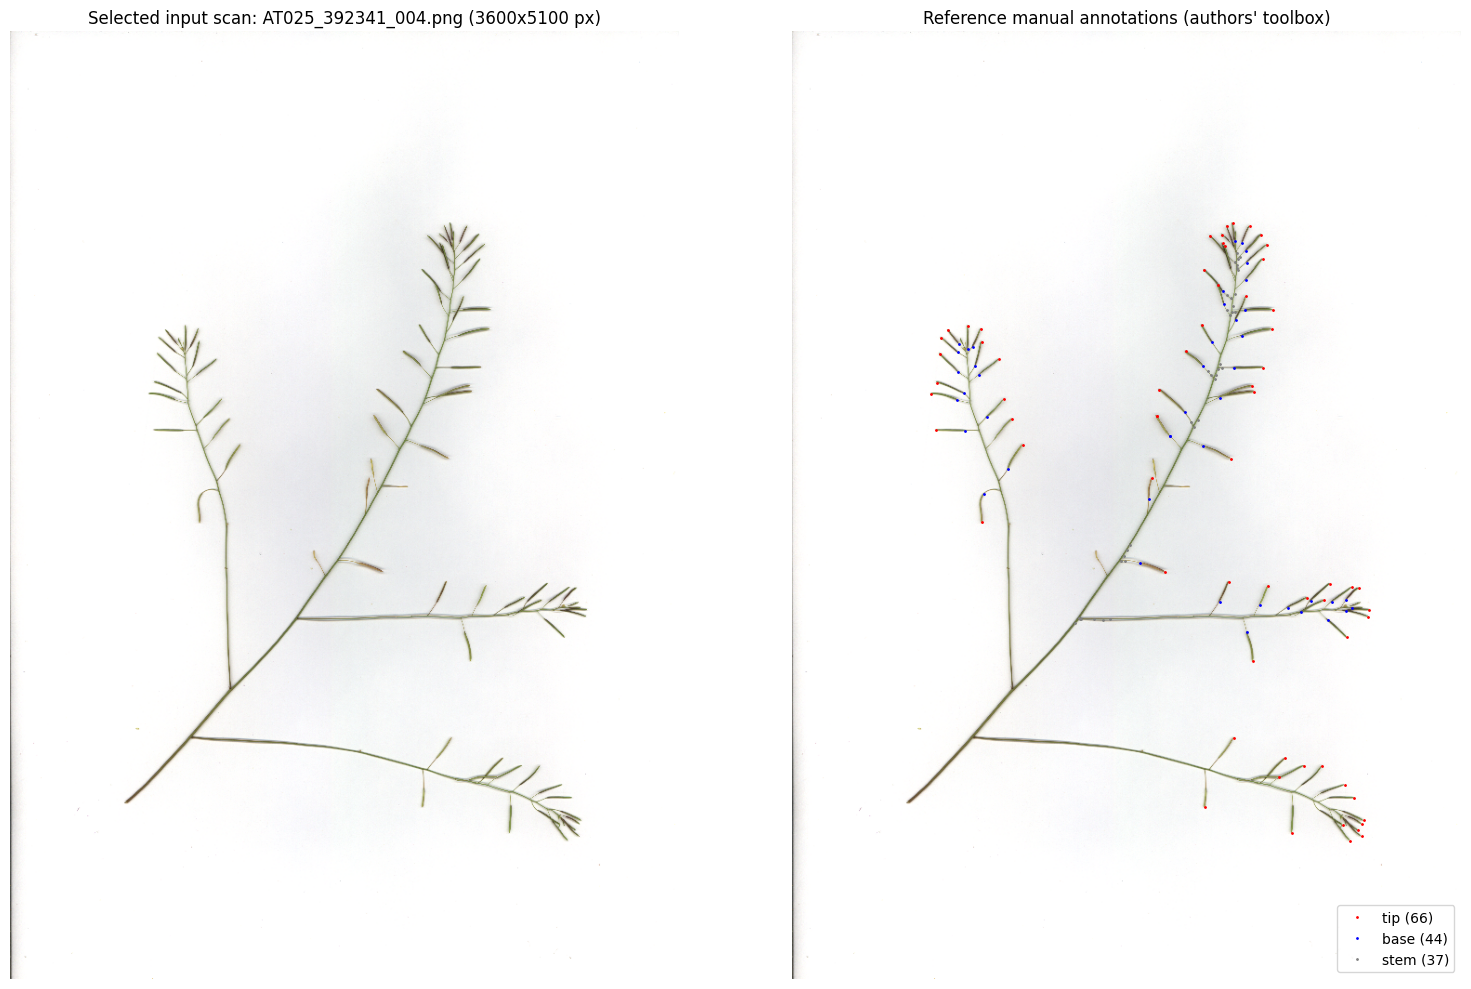

In [ ]:
import matplotlib.pyplot as plt

arr = np.asarray(Image.open(sample_png).convert("RGB"))
IMG_H, IMG_W = arr.shape[:2]
print("scan:", arr.shape)

def load_points(path):
    pts = []
    for line in path.read_text().strip().splitlines():
        parts = line.replace(";", ",").split(",")
        pts.append((float(parts[0]), float(parts[1])))
    return np.array(pts)

ann = {c: load_points(DATA / (SAMPLE + f"_{c}.txt")) for c in ["Tip", "Base", "Stem"]}
for c, p in ann.items():
    print(f"{c}: {len(p)} points, x range {p[:,0].min():.0f}-{p[:,0].max():.0f}, y range {p[:,1].min():.0f}-{p[:,1].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
step = max(IMG_H, IMG_W) // 1200 + 1
axes[0].imshow(arr[::step, ::step])
axes[0].set_title(f"Selected input scan: {SAMPLE}.png ({IMG_W}x{IMG_H} px)")
axes[1].imshow(arr[::step, ::step])
axes[1].plot(ann["Tip"][:, 0] / step, ann["Tip"][:, 1] / step, ".", color="red", ms=2, label=f"tip ({len(ann['Tip'])})")
axes[1].plot(ann["Base"][:, 0] / step, ann["Base"][:, 1] / step, ".", color="blue", ms=2, label=f"base ({len(ann['Base'])})")
axes[1].plot(ann["Stem"][:, 0] / step, ann["Stem"][:, 1] / step, ".", color="gray", ms=2, label=f"stem ({len(ann['Stem'])})")
axes[1].legend(loc="lower right")
axes[1].set_title("Reference manual annotations (authors' toolbox)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/preview_input.png", dpi=80)
plt.show()
TIP_COUNT = len(ann["Tip"])
BASE_COUNT = len(ann["Base"])


### 7. Phase 1 — patching with the authors' MATLAB code (via Octave) / フェーズ1: パッチ生成

**EN:** This runs the authors' **verbatim** functions `Partitioning` → `PatchCentralization` (pinned commit), driven by a thin single-image adaptation of their `Demo_Patching.m` (same parameters: P=32, q=16 overlap, Otsu binarization + `bwlabel` plant mask, border threshold Th.Border=10). Outputs: `indexindicator.mat` (patch grid metadata + binary mask patches) and the centralized RGB patches as a uint8 array — byte-identical to the authors' per-patch PNG writes (PNG is lossless), stored as one array to avoid tens of thousands of tiny files.
**JA:** 著者の関数（`Partitioning` → `PatchCentralization`）を**原文のまま** Octave で実行します。ドライバは `Demo_Patching.m` の単一画像版（P=32、q=16、Otsu 二値化 + `bwlabel`、Th.Border=10）。出力は `indexindicator.mat` と中央化 RGB パッチ（uint8 配列。PNG は可逆なので著者の個別 PNG 保存とバイト等価）。


In [ ]:
PHASE1_M = "\npkg load image;\naddpath('/content/deeppod/silique counting');\n\n%% Single-image adaptation of the authors' Demo_Patching.m (parameters unchanged)\nim = imread('__SAMPLE_PATH__');\n[R.r, R.c, R.d] = size(im);\nIgray = rgb2gray(im);\nIgray = im2bw(Igray, graythresh(Igray));\n[L, ~] = bwlabel(imcomplement(Igray));\nL = L > 0;\nP = 32;                % patch size (authors' P)\nq = P/2;               % 50% overlap (authors' q)\nTh.Border = 10;        % authors' blank-patch threshold\n[Patches, R.BlX, R.BlY, R.PadX, R.PadY] = Partitioning(L, P, q);\nPatchesRGB = [];\nfor ii = 1:size(im,3)\n    [tmp, ~, ~, ~, ~] = Partitioning(im(:,:,ii), P, q);\n    PatchesRGB(:,:,:,ii) = tmp;\nend\n[TestPatches, TestRGBpatches, Index] = PatchCentralization(Patches, PatchesRGB, L, im, P, q, Th);\n\noutdir = '/content/work/test/1';\nif exist(outdir, 'dir') ~= 7; mkdir(outdir); end\ncd(outdir);\n%% indexindicator.mat: fields used by the counting stage (funcTiling).\n%% PatchesRGB is omitted (unused downstream) to halve the file size.\nsave('-v7', 'indexindicator.mat', 'Index', 'R', 'P', 'q', 'Patches');\nTestRGBuint8 = uint8(TestRGBpatches(:,:,Index,:,:));\nsave('-v7', 'centralized_patches.mat', 'TestRGBuint8', 'Index');\nprintf('image %dx%dx%d | grid BlY=%d BlX=%d | centralized patches: %d\\n', R.r, R.c, R.d, R.BlY, R.BlX, numel(Index));\n"
pathlib.Path("/content/phase1.m").write_text(PHASE1_M.replace("__SAMPLE_PATH__", str(sample_png)))

t0 = time.time()
sh(["octave", "--quiet", "--eval", "run('/content/phase1.m')"], capture=True)
print(f"Phase 1 finished in {time.time()-t0:.0f} s")


+ octave --quiet --eval run('/content/phase1.m')


image 5100x3600x3 | grid BlY=318 BlX=224 | centralized patches: 3687

Phase 1 finished in 141 s


### 8. Classify the centralized patches / パッチ分類

**EN:** All centralized patches (uint8 RGB → subtract the training mean image) are classified with the converted DenseNet on the selected device. Results are written to `results.txt` in **exactly the format the authors' `funcReadData.m` parses** (`"<n>.png base:… body:… stem:… tip:…"`), so the counting stage can consume them unchanged.
**JA:** 全中央化パッチ（uint8 RGB − 学習平均画像）を変換済み DenseNet で分類します。結果は著者の `funcReadData.m` が解釈する**同一フォーマット**（`"<n>.png base:… body:… stem:… tip:…"`）で `results.txt` に書き出し、カウント段階でそのまま利用します。


In [ ]:
import scipy.io as sio

mat = sio.loadmat("/content/work/test/1/centralized_patches.mat")
Xp = mat["TestRGBuint8"]            # (P, P, N, 3) uint8
Index = mat["Index"].ravel()
N = Xp.shape[2]
print("centralized patches:", N, "of grid", mat["Index"].shape)

# same verified convention as the val_db check: BGR patch minus RGB-ordered mean
Xn = Xp.transpose(2, 3, 0, 1).astype(np.float32)[:, ::-1] - MEAN[None]

# small batches: the runner keeps every layer output alive, so activation
# memory scales with batch size (dense blocks at 32x32/16x16 resolution)
BATCH = 256 if device.type == "cpu" else 512
t0 = time.time()
probs = []
with torch.no_grad():
    for i in range(0, N, BATCH):
        xb = torch.from_numpy(np.ascontiguousarray(Xn[i:i+BATCH])).to(device)
        out = caffe_forward(xb, layers, W)["softmax"]
        probs.append(out.float().cpu())
        print(f"  classified {i + xb.shape[0]}/{N} patches", flush=True)
probs = torch.cat(probs).numpy()
dt = time.time() - t0
print(f"classified {N} patches in {dt:.1f} s on {device}")

ids = CLASS_IDS  # {'tip','base','body','stem'} -> output slot of the converted net
with open("/content/work/results.txt", "w") as f:
    for n in range(1, N + 1):
        p = probs[n - 1]
        f.write(f"{n}.png base:{p[ids['base']]:.6f} body:{p[ids['body']]:.6f} "
                f"stem:{p[ids['stem']]:.6f} tip:{p[ids['tip']]:.6f}\n")
names = ["tip", "body", "base", "stem"]
for cname in names:
    share = probs[:, ids[cname]].mean()
    print(f"mean prob {cname:5s}: {share:.3f}")


centralized patches: 3687 of grid (1, 3687)


  classified 512/3687 patches


  classified 1024/3687 patches


  classified 1536/3687 patches


  classified 2048/3687 patches


  classified 2560/3687 patches


  classified 3072/3687 patches


  classified 3584/3687 patches


  classified 3687/3687 patches


classified 3687 patches in 3.4 s on cuda
mean prob tip  : 0.092
mean prob body : 0.327
mean prob base : 0.094
mean prob stem : 0.486


### 9. Phase 2 — reconstruction + silique counting (authors' functions, verbatim) / フェーズ2: 再構成とサイレーク計数

**EN:** A thin single-image adaptation of the authors' `Demo_counter.m` calls their own functions: `funcReadData` (parse `results.txt`), `funcTiling` (majority-vote reconstruction over 16×16 sub-patches), `funcSiliqdef` (merge tip+body+base regions), and `funcSiliqCounting` (split clear vs crossed siliques, `regionprops`/`bwdist`/`imextendedmin` logic with the authors' thresholds: eccentricity 0.97, tip/base area 20 px). We report both `no_clear_Sil` (unambiguous siliques) and `no_all` (clear + crossed estimates) — the paper's automated count.
**JA:** 著者の `Demo_counter.m` の単一画像版として、著者本人の関数（`funcReadData`, `funcTiling`, `funcSiliqdef`, `funcSiliqCounting`、しきい値 0.97/20px を含む）をそのまま呼び出します。出力は明確なサイレーク数 `no_clear_Sil` と交差推定込みの `no_all`（論文の自動計数値）。


In [ ]:
# Minimal compatibility guard for the authors' funcSiliqCounting.m: when an
# image contains no *clear* siliques, Measurments_struct is referenced
# uninitialized (struct2cell at line 46) and would crash. We initialize it as
# an empty struct with the expected fields; behavior is unchanged otherwise.
# (AI-added guard, documented in the report.)
fsc = DEEPPOD / "silique counting/funcSiliqCounting.m"
txt = fsc.read_text()
guard = "clear Measurments_struct\n"
ai_line = "Measurments_struct = struct('MinorAxisLength', {}, 'MajorAxisLength', {}, 'Perimeter', {}, 'Area', {});  % AI-added guard\n"
if ai_line not in txt:  # idempotent: safe when the notebook is re-run in one session
    assert guard in txt
    txt = txt.replace(guard, guard + ai_line, 1)
    assert ai_line in txt
    fsc.write_text(txt)

PHASE2_M = "\npkg load image;\naddpath('/content/deeppod/silique counting');\naddpath('/content/work/test/1');\n\n%% Single-image adaptation of the authors' Demo_counter.m (type_net='D' path)\nfid = fopen('/content/work/results.txt', 'r');\nC = funcReadData(fid);\nfclose(fid);\nim_out = funcTiling('/content/work/test/1', C);\nSil_def_im = funcSiliqdef(im_out);\n[no_all, no_clear_Sil, Measurments] = funcSiliqCounting(Sil_def_im, im_out);\n\nsave('-v7', '/content/work/phase2_results.mat', 'im_out', 'Sil_def_im', 'no_all', 'no_clear_Sil');\nprintf('automated count (no_all) = %d | clear siliques = %d\\n', no_all, no_clear_Sil);\n"
pathlib.Path("/content/phase2.m").write_text(PHASE2_M)

t0 = time.time()
sh(["octave", "--quiet", "--eval", "run('/content/phase2.m')"], capture=True)
print(f"Phase 2 finished in {time.time()-t0:.0f} s")

res = sio.loadmat("/content/work/phase2_results.mat")
im_out = res["im_out"]
Sil_def_im = res["Sil_def_im"]
no_all = int(res["no_all"].item())
no_clear = int(res["no_clear_Sil"].item())
print("label map:", im_out.shape, "values:", sorted(np.unique(im_out).tolist()))


+ octave --quiet --eval run('/content/phase2.m')


automated count (no_all) = 56 | clear siliques = 41

Phase 2 finished in 343 s


label map: (5100, 3600) values: [0.0, 1.0, 2.0, 3.0, 4.0]


### 10. Result: reconstruction and detected siliques / 結果の可視化

**EN:** The label map reconstructed by sub-patch voting (colors: **tip** red, **body** green, **base** blue, **stem** white; background black — the authors' suggested colormap) and the per-silique regions after the authors' tip–body–base merging and cross-silique splitting.
**JA:** サブパッチ多数決で再構成されたラベルマップ（**tip**=赤、**body**=緑、**base**=青、**stem**=白、背景=黒：著者提示のカラーマップ）と、tip–body–base 統合・交差分離後の個体サイレーク領域。


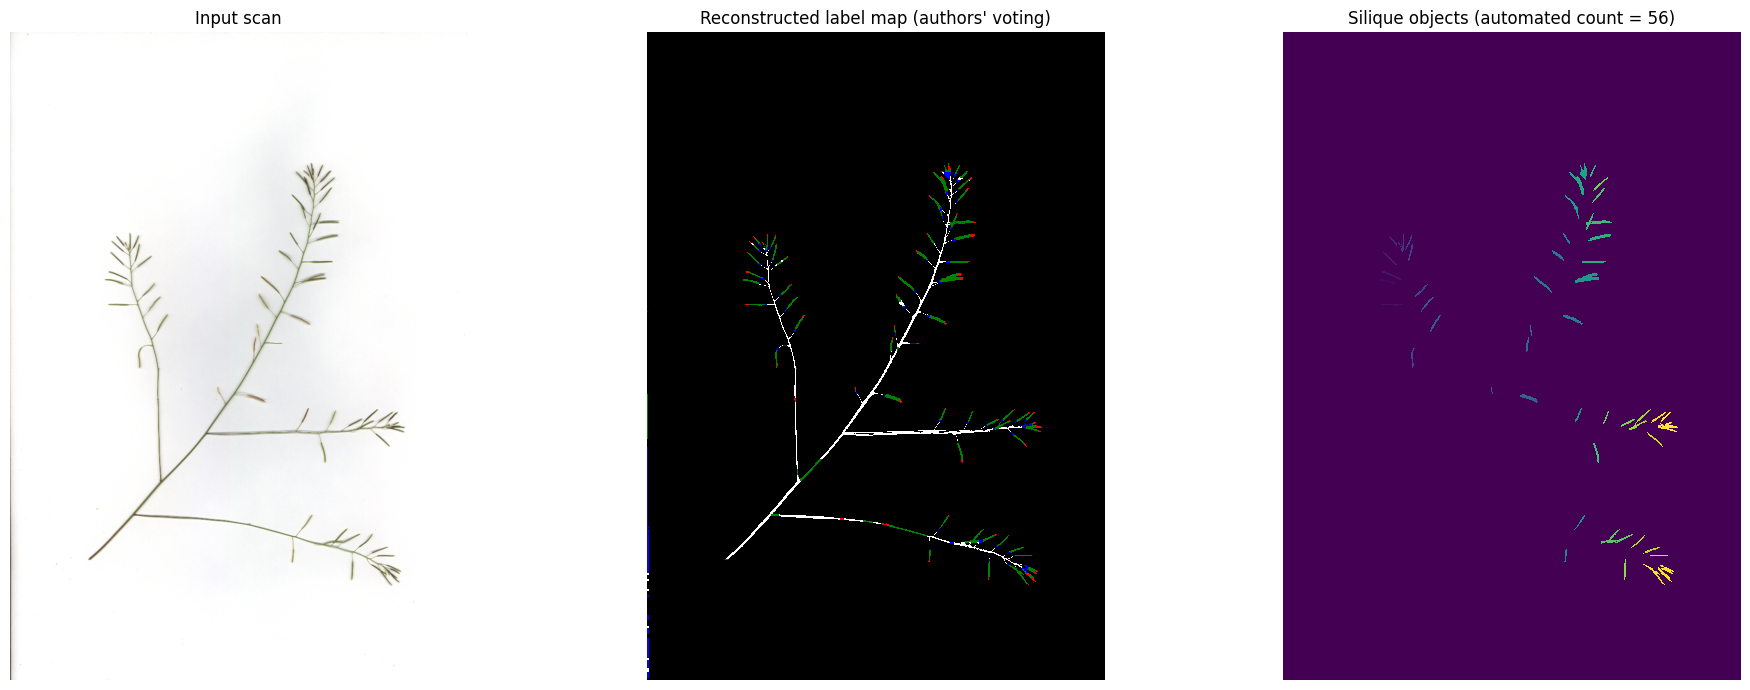

no_all (clear + crossed): 56 | no_clear: 41


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(arr[::4, ::4])
axes[0].set_title("Input scan")
cmap = plt.cm.colors.ListedColormap(["black", "red", "green", "blue", "white"])
axes[1].imshow(im_out[::4, ::4], cmap=cmap, vmin=0, vmax=4, interpolation="nearest")
axes[1].set_title("Reconstructed label map (authors' voting)")
axes[2].imshow(Sil_def_im[::4, ::4], cmap="viridis", interpolation="nearest")
axes[2].set_title(f"Silique objects (automated count = {no_all})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/deeppod_result.png", dpi=80)
plt.show()
print("no_all (clear + crossed):", no_all, "| no_clear:", no_clear)


### 11. Automated vs annotation-derived reference count / 自動計数と参照カウントの比較

**EN:** The automated count is compared with the **annotation-derived fruit count** of this sample: the number of manually annotated tips (and, independently, bases) — each fruit has exactly one tip and one base, so both are expected to equal the fruit number. This is a proxy for the paper's ImageJ manual count, whose per-image CSVs are only distributed inside the currently unreachable Set_1.tar; treat it as a labeled reference, not the published count table. The paper reports DenseNet correlation 0.954 / RMSE 12.45 on the Set-1 development test with a tendency to underestimate. A single image only illustrates the pipeline; it is not a dataset-level verification.
**JA:** 自動計数値を、本サンプルの手動アノテーション由来の果実数（tip 点数、および独立に base 点数。果実 1 本につき各 1 点）と比較します。これは論文の ImageJ 手動カウントの代理参照であり（画像ごとのカウント CSV は現在取得不可の Set_1.tar のみに収録）、公開カウント表そのものではない点に注意してください。単一画像はパイプラインの例示であり、データセット全体の検証ではありません。


In [ ]:
import pandas as pd

comparison = pd.DataFrame(
    {"value": [no_all, no_clear, TIP_COUNT, BASE_COUNT, no_all - TIP_COUNT, no_clear - TIP_COUNT]},
    index=["automated no_all (clear+crossed)", "automated no_clear (clear only)",
           "reference: annotated tips", "reference: annotated bases",
           "diff (no_all - tips)", "diff (no_clear - tips)"],
)
display(comparison)
comparison.to_csv("/content/deeppod_count_comparison.csv")
print("saved /content/deeppod_count_comparison.csv")


,value
automated no_all (clear+crossed),56
automated no_clear (clear only),41
reference: annotated tips,66
reference: annotated bases,44
diff (no_all - tips),-10
diff (no_clear - tips),-25


saved /content/deeppod_count_comparison.csv


## Interpretation, differences from the paper, and references / 解釈と参考文献

**EN:** This notebook executed the DeepPod pipeline end-to-end on **one** Set-1 scan: authors' patching, converted pretrained DenseNet classification, authors' reconstruction and counting. Differences from the authors' environment: Caffe→PyTorch weight conversion (validated on `val_db` in §4, including the BGR/mean-file channel convention), MATLAB→Octave for the verbatim counting functions, file-arrangement adaptations (patches as arrays instead of ~10⁴ PNGs), a documented one-line guard in `funcSiliqCounting.m`, and the use of a GigaDB sample with annotation-derived reference counts (the full Aberystwyth archives are currently Cloudflare-blocked). Not verified here: dataset-level accuracy (Set-2 R²=0.90), patch-classifier confusion matrices, training, and supplementary length analyses.
**JA:** 本ノートブックは Set-1 の**1 枚**に対して DeepPod パイプライン（著者のパッチ生成 → 変換済み DenseNet → 著者の再構成・計数）を通しで実行しました。著者環境との差分: Caffe→PyTorch 変換（§4 で検証 DB により検証）、MATLAB→Octave、ファイル配置の簡略化。未検証: データセットレベルの精度、混同行列、学習、補足の長さ解析。

**References / 参考文献**
- Paper: GigaScience 9(3):giaa012 (2020), DOI 10.1093/gigascience/giaa012.
- Code: AzmHmd/DeepPod @ `d7cff986c9a64766ca5351d1cce7e04ca493944d` (MIT).
- Weights: `trained models/densenet/snapshot_iter_157380.caffemodel` (same commit).
- Data: GigaDB record 100704 (DOI 10.5524/100704); the selected Set-1 scan and its Tip/Stem/Base annotation .txt are fetched via GigaDB's public API file listing (Wasabi S3 mirror, GigaDB file ids 382313-382316); full archives: Aberystwyth DOI 10.20391/21154739-f718-457b-96ff-838408f2b696 (currently inaccessible to datacenter clients).
- Caffe protobuf schema: BVLC/caffe @ `9b891540183ddc834a02b2bd81b31afae71b2153`.
- Investigation metadata (PhenoPaper run p-…-20260930T152634Z-3756924) used as prior research guidance only.
